# 11. Clustering

### Objetivo: <br>

Agrupar indivíduos segundo padrões de funcionalidade, identificar perfis homogéneos, e estudar a sua relação com quedas e indicadores clínicos.

Abordagem : <br>
-> Pre-processamento <br>
-> Clustering com/sem outcomes <br>

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_ind, f_oneway, mannwhitneyu, kruskal, chi2_contingency, fisher_exact

### 0.1 - Configurações <br>

A célula abaixo define as configurações mais importantes do clustering: <br> 
    • Variável "outcomes" define se o clustering usa colunas de outcome ou não (True/False); <br>
    • Variável "model" define o modelo usado (kmeans/gmm) <br>
    • k define o número de clusters


In [30]:
outcomes = True # True ou False 
model_choice = "gmm" # "kmeans" ou "gmm"
k_choice = 2 # 

## 1. Preprocessing

In [31]:
df = pd.read_csv("../data/interim/09. FRAIL_LLM.csv")

df.columns
df_full = df.copy()  # mantém todas as colunas no df_full
df.shape

(6705, 69)

### Passo 1: <br>
Remover colunas que não interessam para o clustering. Começa-se pelas colunas triviais (ids, locais, datas, etc). <br>

Os outcomes podem ser retirados/mantidos, definindo a variavel outcomes a False / True

In [32]:
# Remover variaveis desinteressantes para o clustering

def drop_columns(outcomes):

    if outcomes:
        drop = [
            "ID_Aluno",
            "Momento",
            "Local_de_Avaliacao",
            "Data_avaliacao",
            "Data_nascimento",
            "Escolaridade",
            "MMSE_EDUCAÇAO",
            "Quedas_ultimos_12meses",
            "Quedas_12meses_Assistencia_hospitalar_Sim_Não",
            "Quedas_12meses_Hospitalizado_Dias",
            "Quedas_12meses_Hospitalizado_Sim_Não",
            "Quedas_12meses_Lesao_Gravidade",
            "Quedas_12meses_Lesao_Local",
            "Quedas_12meses_Lesao_Sim_Nao",
            "Quedas_12meses_Lesao_Tipo",
            "Quedas_12meses_Situacao",
            "Quedas_12meses_Lesao_Local_Gravidade",
            "@6_MIN_ANDAR_Parou_Motivo",
        ]
    else:
        drop = [
            "ID_Aluno",
            "Momento",
            "Local_de_Avaliacao",
            "Data_avaliacao",
            "Data_nascimento",
            "Escolaridade",
            "MMSE_EDUCAÇAO",
            "Quedas_ultimos_12meses",
            "Quedas_12meses_Quantas",
            "Quedas_12meses_Assistencia_hospitalar_Sim_Não",
            "Quedas_12meses_Hospitalizado_Dias",
            "Quedas_12meses_Hospitalizado_Sim_Não",
            "Quedas_12meses_Lesao_Gravidade",
            "Quedas_12meses_Lesao_Local",
            "Quedas_12meses_Lesao_Sim_Nao",
            "Quedas_12meses_Lesao_Tipo",
            "Quedas_12meses_Situacao",
            "Quedas_12meses_Situacao_score",
            "Quedas_12meses_Medo_cair_Sim_Não",
            "Quedas_12meses_Lesao_Local_Gravidade",
            "@6_MIN_ANDAR_Parou_Motivo",
        ]

    df.drop(columns=drop, inplace=True, errors="ignore")

    return df

# Chamar a função para dropar as colunas
df = drop_columns(outcomes)

In [33]:
df.columns

Index(['Age', 'Genero', 'Modalidade', 'Freq_semanal',
       'ANTROPOMETRIA_Estatura_cm', 'ANTROPOMETRIA_Peso_Kg',
       'Quedas_12meses_Quantas', 'Quedas_12meses_Medo_cair_Sim_Não',
       'ATIVIDADE_FISICA_Geral_Sim_Não',
       'ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana',
       'ANTROPOMETRIA_Massa_gorda', 'ANTROPOMETRIA_Massa_magra_Kg',
       'ANTROPOMETRIA_Gordura_visceral', 'HANDGRIP_Mao_DOMINANTE',
       'HANDGRIP_DIREITA_tentaiva1', 'HANDGRIP_DIREITA_tentativa2',
       'HANDGRIP_DIREITA_tentativa_3', 'HANDGRIP_ESQUERDA_tentativa1',
       'HANDGRIP_ESQUERDA_tentativa2', 'HANDGRIP_ESQUERDA_tentativa3',
       'TIMED_UP_AND_GO_Simples_tentativa1',
       'TIMED_UP_AND_GO_Simples_tentativa2', 'Best_TIMED_UP_AND_GO_Simples',
       'Percentil_TIMED_UP_AND_GO_Simples',
       'TIMED_UP_AND_GO_Simples_Apoio_mãos',
       'TIMED_UP_AND_GO_Simples_Auxiliar_marcha',
       'TIMED_UP_AND_GO_Dupla_tarefa_tentativa1',
       'TIMED_UP_AND_GO_Dupla_tarefa_tentativa2',
       'B

Após remover as colunas mais óbvias, continuamos com demasiadas variáveis. Com algum feature engineering, conseguimos diminuir este número de variáveis:

In [34]:
# best = 1 para melhor valor, 0 para média (resultados semelhantes)

def feature_engineering(df, df_full, best = True): 

    # Criar coluna Handgrip_Best = melhor valor entre todas as tentativas (direita e esquerda) ou média
    
    handgrip_cols = [
        "HANDGRIP_DIREITA_tentaiva1",
        "HANDGRIP_DIREITA_tentativa2",
        "HANDGRIP_DIREITA_tentativa_2",
        "HANDGRIP_DIREITA_tentativa_3",
        "HANDGRIP_ESQUERDA_tentativa1",
        "HANDGRIP_ESQUERDA_tentativa2",
        "HANDGRIP_ESQUERDA_tentativa3",
    ]

    # filtra e calcula o valor médio / máximo
    handgrip_cols = [c for c in handgrip_cols if c in df.columns]

    if best == 0:
        df["Handgrip_Best"] = df[handgrip_cols].mean(axis=1)
        df_full["Handgrip_Best"] = df[handgrip_cols].mean(axis=1)
    else:
        df["Handgrip_Best"] = df[handgrip_cols].max(axis=1)
        df_full["Handgrip_Best"] = df[handgrip_cols].max(axis=1)

    # remover colunas de handgrip individuais e a coluna de mão dominante
    X = df.drop(columns=handgrip_cols, errors="ignore")
    X = X.drop(columns=["HANDGRIP_Mao_DOMINANTE"], errors="ignore")

    # Apoio de mãos é semelhante nas duas variantes do TUG. Combinar numa só coluna
    simples, dupla = "TIMED_UP_AND_GO_Simples_Apoio_mãos", "TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos"

    # Coluna combinada (se apoio em qualquer uma das variantes, então 1)
    X["TUG_Apoio_maos"] = ((X[simples] == 1) | (X[dupla] == 1)).astype(int)
    df_full["TUG_Apoio_maos"] = ((df_full[simples] == 1) | (df_full[dupla] == 1)).astype(int)

    X.drop(columns=[simples, dupla], inplace=True)

    # "@6_MIN_ANDAR_Parou" e "@6_MIN_ANDAR_Parou_Quantas_vezes" é tambem 99.9% igual, manter apenas "Parou quantas vezes" (mais informativa)
    X.drop(columns=["@6_MIN_ANDAR_Parou"], inplace=True)

    return X, df_full

# Aplicar feature engineering
X, df_full = feature_engineering(df, df_full, best = True)

X.shape

(6705, 46)

Outras redundancias (variáveis derivadas umas das outras): <br>

6_MIN_ANDAR_N_voltas_completas <-> 6_MIN_ANDAR_Distancia_TOTAL_metros <-> Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros <br>

Best_TIMED_UP_AND_GO_Simples <-> Percentil_TIMED_UP_AND_GO_Simples

Best_TIMED_UP_AND_GO_Dupla_tarefa <-> Percentil_TIMED_UP_AND_GO_Dupla_tarefa

SIT_TO_STAND_Repetiçoes <-> Percentil_SIT_TO_STAND_Repetiçoes


In [35]:
def drop_redundant_columns(X):
    # Retirar redundancias do feature set 
    drop = [
        "@6_MIN_ANDAR_Distancia_TOTAL_metros",
        "Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros",
        "Percentil_TIMED_UP_AND_GO_Simples",
        "Percentil_TIMED_UP_AND_GO_Dupla_tarefa",
        "Percentil_SIT_TO_STAND_Repetiçoes",
    ]

    X = X.drop(columns=drop, errors="ignore")
    return X

X = drop_redundant_columns(X)

### Passo 2: <br>

Normalizar e remover features correlacionadas

In [36]:
def scale_features(X):
    # Standardizar features
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    # scaler 
    scaler =  StandardScaler()

    _cols = X.columns.copy()
    _idx  = X.index.copy()
    X_scaled = scaler.fit_transform(X.values)
    X = pd.DataFrame(X_scaled, columns=_cols, index=_idx)

    return X

X = scale_features(X)

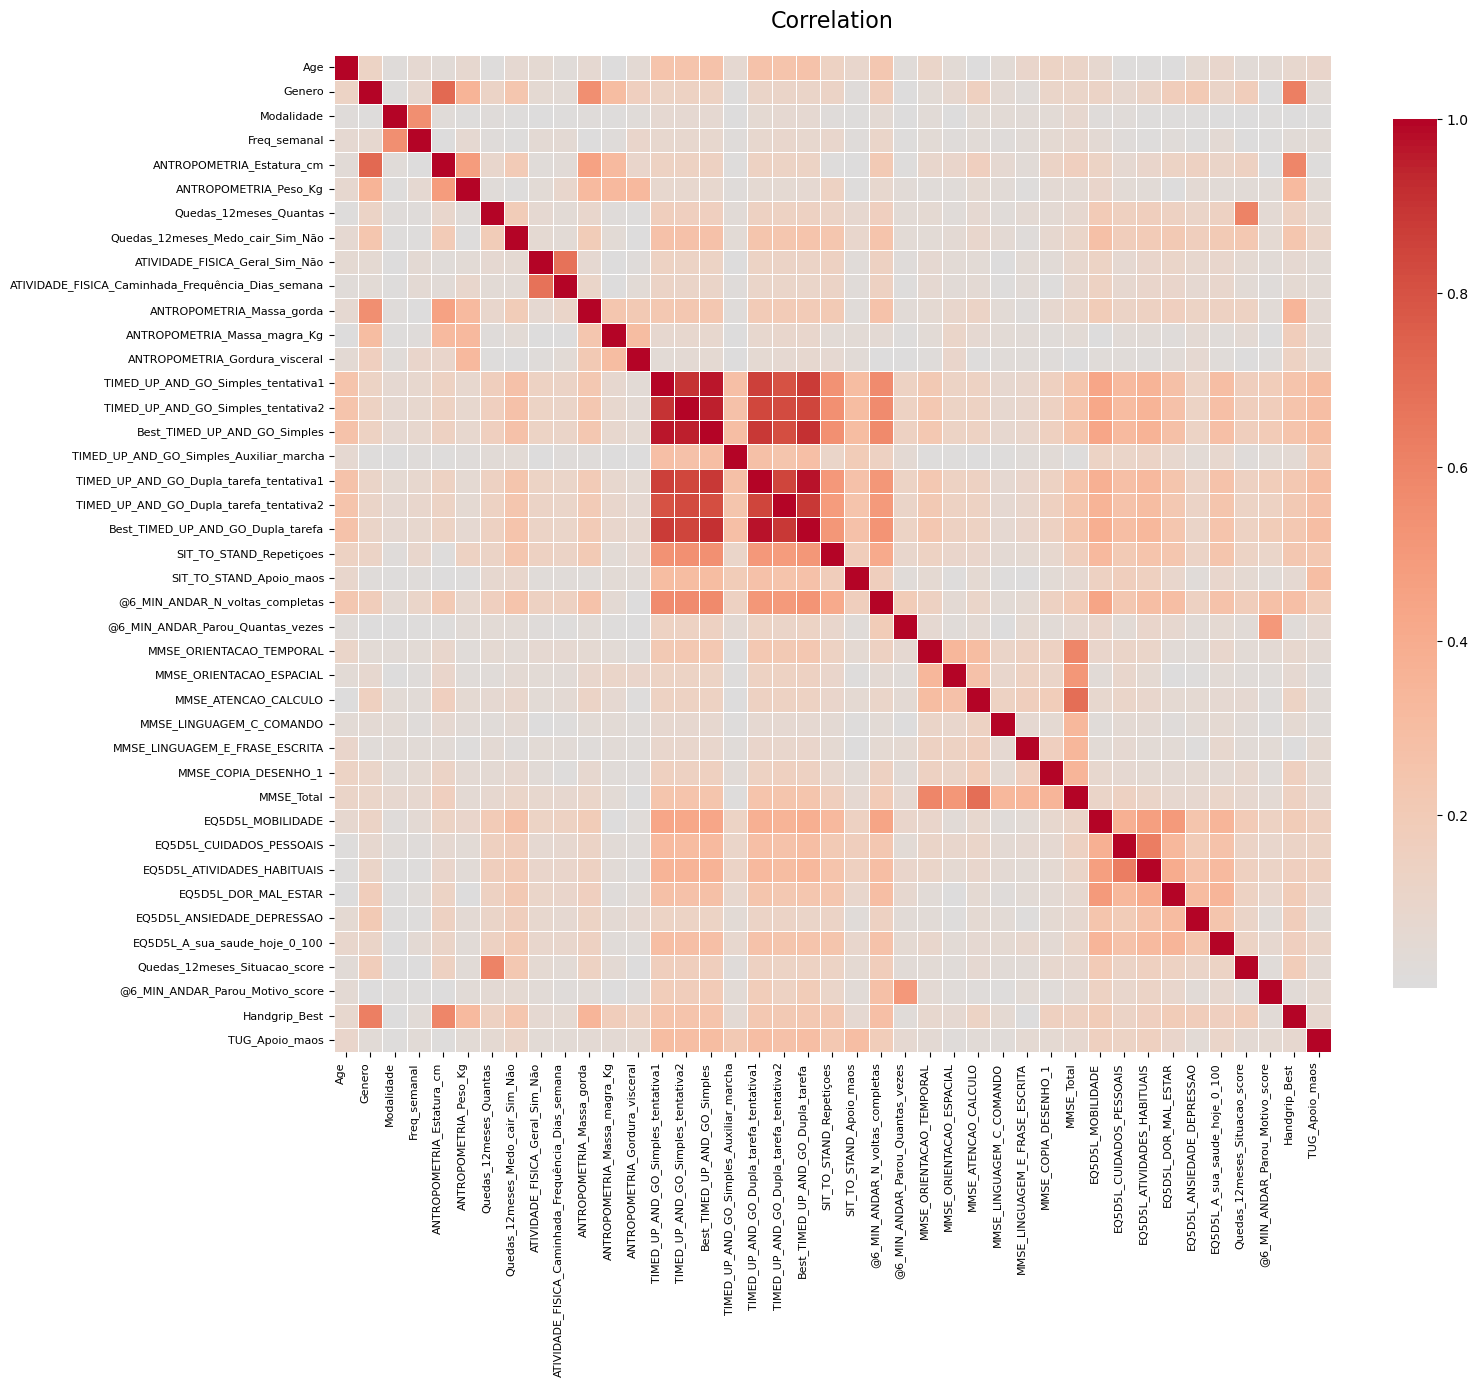

In [37]:
# Visualizar matriz de correlação
corr = X.corr().abs()

plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation", fontsize=16, pad=20)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [38]:
# Identificar pares de features com alta correlação (> 0.9)
high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ["feature_1", "feature_2", "corr"]

high_corr_pairs = high_corr_pairs[high_corr_pairs["corr"] > 0.9].sort_values("corr", ascending=False)

print("Pares com correlação > 0.9:")
print(high_corr_pairs.to_string(index=False))

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

Pares com correlação > 0.9:
                              feature_1                          feature_2     corr
TIMED_UP_AND_GO_Dupla_tarefa_tentativa1  Best_TIMED_UP_AND_GO_Dupla_tarefa 0.969867
     TIMED_UP_AND_GO_Simples_tentativa1       Best_TIMED_UP_AND_GO_Simples 0.963681
     TIMED_UP_AND_GO_Simples_tentativa2       Best_TIMED_UP_AND_GO_Simples 0.951619
           Best_TIMED_UP_AND_GO_Simples  Best_TIMED_UP_AND_GO_Dupla_tarefa 0.907521
     TIMED_UP_AND_GO_Simples_tentativa1 TIMED_UP_AND_GO_Simples_tentativa2 0.905810


In [39]:
def drop_correlated_features(X):
    # Drop de features altamente correlacionadas (manter apenas uma de cada par)
    to_drop = [
        "TIMED_UP_AND_GO_Simples_tentativa1",
        "TIMED_UP_AND_GO_Simples_tentativa2",
        "TIMED_UP_AND_GO_Dupla_tarefa_tentativa1",
        "TIMED_UP_AND_GO_Dupla_tarefa_tentativa2",
        "Best_TIMED_UP_AND_GO_Simples"
    ]

    X = X.drop(columns=to_drop, errors="ignore")
    X.shape

    return X

X = drop_correlated_features(X)

In [40]:
# Colunas finais
X.columns

Index(['Age', 'Genero', 'Modalidade', 'Freq_semanal',
       'ANTROPOMETRIA_Estatura_cm', 'ANTROPOMETRIA_Peso_Kg',
       'Quedas_12meses_Quantas', 'Quedas_12meses_Medo_cair_Sim_Não',
       'ATIVIDADE_FISICA_Geral_Sim_Não',
       'ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana',
       'ANTROPOMETRIA_Massa_gorda', 'ANTROPOMETRIA_Massa_magra_Kg',
       'ANTROPOMETRIA_Gordura_visceral',
       'TIMED_UP_AND_GO_Simples_Auxiliar_marcha',
       'Best_TIMED_UP_AND_GO_Dupla_tarefa', 'SIT_TO_STAND_Repetiçoes',
       'SIT_TO_STAND_Apoio_maos', '@6_MIN_ANDAR_N_voltas_completas',
       '@6_MIN_ANDAR_Parou_Quantas_vezes', 'MMSE_ORIENTACAO_TEMPORAL',
       'MMSE_ORIENTACAO_ESPACIAL', 'MMSE_ATENCAO_CALCULO',
       'MMSE_LINGUAGEM_C_COMANDO', 'MMSE_LINGUAGEM_E_FRASE_ESCRITA',
       'MMSE_COPIA_DESENHO_1', 'MMSE_Total', 'EQ5D5L_MOBILIDADE',
       'EQ5D5L_CUIDADOS_PESSOAIS', 'EQ5D5L_ATIVIDADES_HABITUAIS',
       'EQ5D5L_DOR_MAL_ESTAR', 'EQ5D5L_ANSIEDADE_DEPRESSAO',
       'EQ5D5L_A_sua_sau

### Passo 3:

Depois de refinado o feature set, podemos introduzir pesos nas variáveis para depois passar para o clusteirng

In [41]:
def apply_weights(X):
    # Aplicar pesos às features conforme relevância
    weights = {
        # Demografico
        "Genero": 0.6, 

        # Funcionais
        "Handgrip_Best": 1.25,

        # Cognitivos
        "MMSE_ORIENTACAO_TEMPORAL": 0.4,
        "MMSE_ORIENTACAO_ESPACIAL": 0.4,
        "MMSE_ATENCAO_CALCULO": 0.4,
        "MMSE_LINGUAGEM_C_COMANDO": 0.4,
        "MMSE_LINGUAGEM_E_FRASE_ESCRITA": 0.4,
        "MMSE_COPIA_DESENHO_1": 0.4,

        # Qualidade de vida
        "EQ5D5L_CUIDADOS_PESSOAIS": 0.5,
        "EQ5D5L_ATIVIDADES_HABITUAIS": 0.5,
        "EQ5D5L_DOR_MAL_ESTAR": 0.5,
        "EQ5D5L_ANSIEDADE_DEPRESSAO": 0.5,   
    }

    for col, w in weights.items():
        if col in X.columns:
            X[col] *= w
    return X

X = apply_weights(X)

## 2. Clustering

modelo  KMeans    gmm
k                    
2        0.120  0.384
3        0.082  0.090
4        0.087  0.061
5        0.089  0.033
6        0.093  0.044
7        0.083  0.041
8        0.079  0.060
9        0.084  0.055
10       0.078  0.059
11       0.079  0.059
12       0.073  0.054


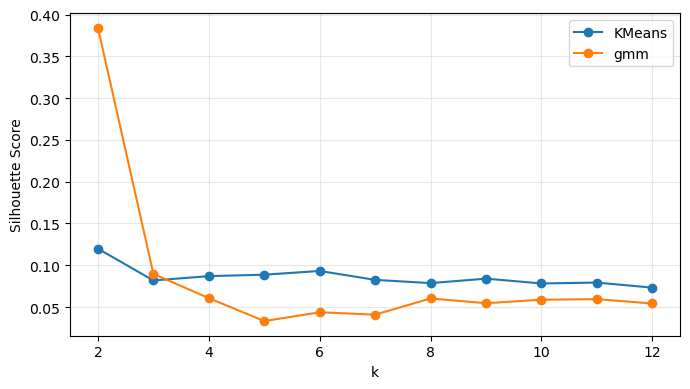

In [42]:
# Clustering com KMeans - silhouette score
X = X.copy()  
rng = 42
ks = range(2, 13) 

models = {
    "KMeans": lambda k: KMeans(n_clusters=k, n_init=20, random_state=rng),
    "gmm": lambda k: GaussianMixture(n_components=k, covariance_type="full", random_state=rng)
}
rows = []

# Loop sobre modelos e valores de k
for name, constructor in models.items():
    for k in ks:
        model = constructor(k)
        labels = model.fit_predict(X)
        sil = silhouette_score(X, labels)
        rows.append((name, k, sil))

df_sil = pd.DataFrame(rows, columns=["modelo", "k", "silhouette"])
print(df_sil.pivot(index="k", columns="modelo", values="silhouette").round(3))


plt.figure(figsize=(7,4))
for name in df_sil["modelo"].unique():
    subset = df_sil[df_sil["modelo"] == name]
    plt.plot(subset["k"], subset["silhouette"], marker="o", label=name)
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# Clustering com o modelo escolhido e k

def fit_predict(model_choice, k, X):
    
    if model_choice == "kmeans":
        km = KMeans(n_clusters=k, n_init=20, random_state=rng)
    
    elif model_choice == "gmm":
        km = GaussianMixture(n_components=k, covariance_type="full", random_state=rng)

    lab = km.fit_predict(X); est = km

    sil = silhouette_score(X, lab)
    return est, lab, sil

rows = []

_, lab, sil = fit_predict(model_choice, k_choice, X)
models = (k_choice, sil, lab)

used_k, sil, winner_labels = models
print(f"\n k={used_k} | silhouette={sil:.3f}")

labels = pd.Series(winner_labels, index=getattr(X, "index", None), name=f"k{used_k}")
print("\nDistribuição dos clusters:")
print(labels.value_counts().sort_index())



 k=2 | silhouette=0.384

Distribuição dos clusters:
k2
0    6283
1     422
Name: count, dtype: int64


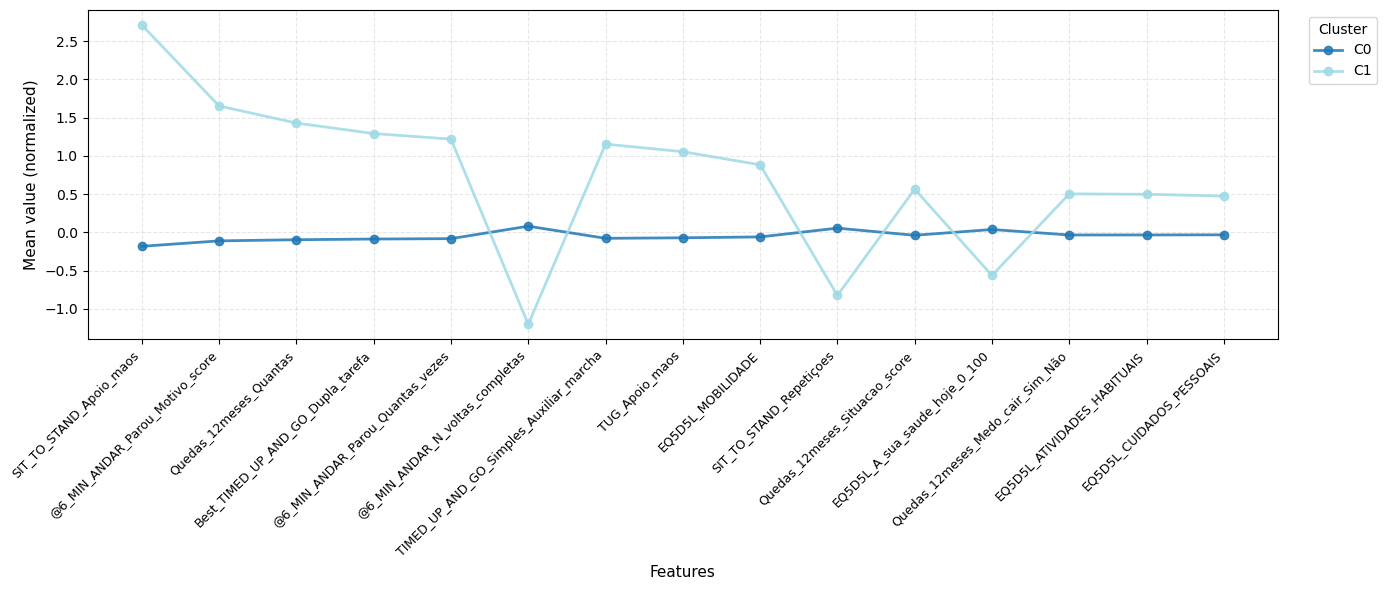

In [44]:
# Análise dos clusters (todos os clusters)

K = 15

# Preparar dados
data = X.copy()
data["cluster"] = labels.values

# médias por cluster (todos)
cluster_means = data.groupby("cluster").mean()

# Top-K features por variância entre clusters
variance = cluster_means.var(axis=0).sort_values(ascending=False)
top_features = variance.index[:K]
cluster_profiles = cluster_means[top_features]

# Criar visualização
plt.figure(figsize=(14, 6))

# cores para todos os clusters
colors = plt.cm.tab20(np.linspace(0, 1, len(cluster_profiles.index)))

for idx, cluster_id in enumerate(cluster_profiles.index):
    plt.plot(
        range(K),
        cluster_profiles.loc[cluster_id],
        marker="o",
        linewidth=2,
        markersize=6,
        label=f"C{cluster_id}",
        color=colors[idx],
        alpha=0.85
    )

plt.xticks(range(K), top_features, rotation=45, ha="right", fontsize=9)
plt.ylabel("Mean value (normalized)", fontsize=11)
plt.xlabel("Features", fontsize=11)
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

In [45]:
# Z-scores (médias por cluster nas features selecionadas)
print("\n=== Z-scores (cluster means) used in the plot ===")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    print(cluster_profiles.round(3).to_string())


=== Z-scores (cluster means) used in the plot ===
         SIT_TO_STAND_Apoio_maos  @6_MIN_ANDAR_Parou_Motivo_score  Quedas_12meses_Quantas  Best_TIMED_UP_AND_GO_Dupla_tarefa  @6_MIN_ANDAR_Parou_Quantas_vezes  @6_MIN_ANDAR_N_voltas_completas  TIMED_UP_AND_GO_Simples_Auxiliar_marcha  TUG_Apoio_maos  EQ5D5L_MOBILIDADE  SIT_TO_STAND_Repetiçoes  Quedas_12meses_Situacao_score  EQ5D5L_A_sua_saude_hoje_0_100  Quedas_12meses_Medo_cair_Sim_Não  EQ5D5L_ATIVIDADES_HABITUAIS  EQ5D5L_CUIDADOS_PESSOAIS
cluster                                                                                                                                                                                                                                                                                                                                                                                                                                                    
0                         -0.182                           -0

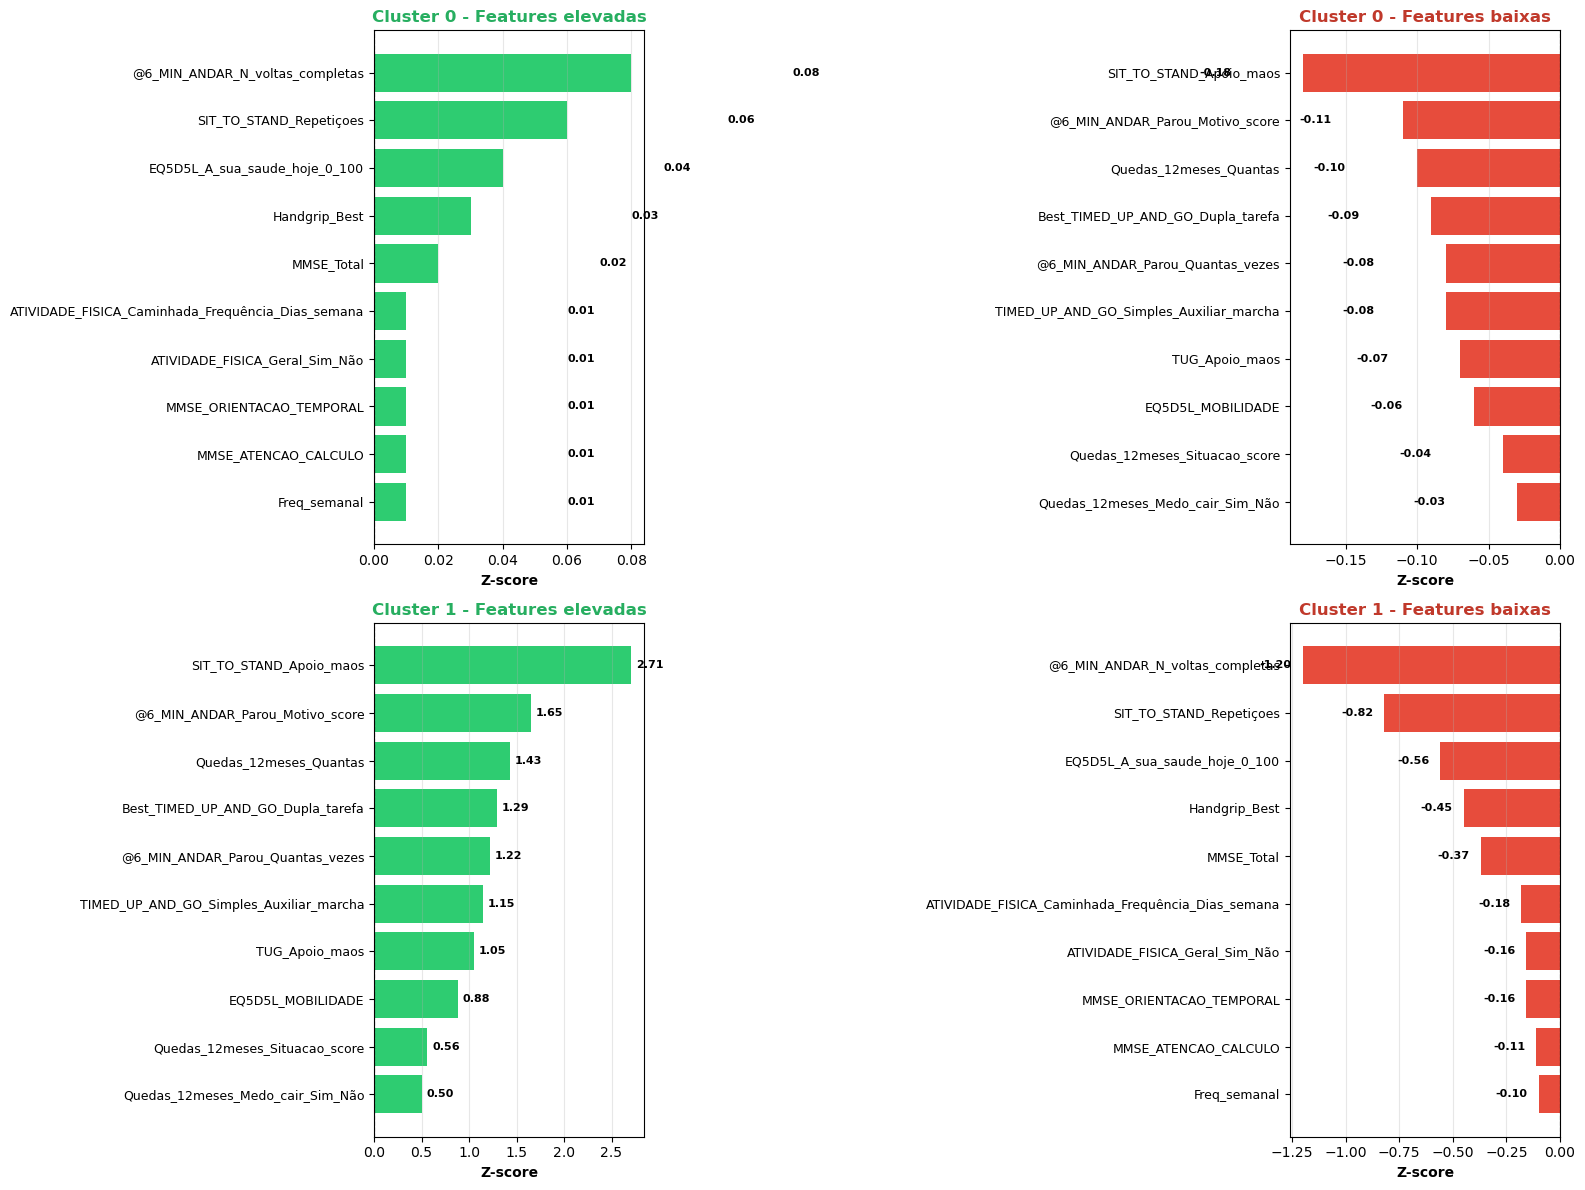

In [46]:
# Perfis: média por cluster em espaço escalado
tmp = X.copy()
tmp["cluster"] = labels.values
profiles = tmp.groupby("cluster").mean()

# Ordenar features pelas que mais diferenciam clusters
order = profiles.var(axis=0).sort_values(ascending=False).index
profiles = profiles[order]
profiles_z = profiles.copy()

# Top features por cluster
topk = 10
tops = {}
for c in profiles_z.index:
    s = profiles_z.loc[c]
    pos = s.sort_values(ascending=False).head(topk)
    neg = s.sort_values(ascending=True).head(topk)
    tops[int(c)] = {
        "higher": list(zip(pos.index.tolist(), np.round(pos.values, 2))),
        "lower": list(zip(neg.index.tolist(), np.round(neg.values, 2))),
    }

# Visualização dos top features por cluster
n_clusters = len(tops)
fig, axes = plt.subplots(n_clusters, 2, figsize=(16, 6*n_clusters))
if n_clusters == 1:
    axes = axes.reshape(1, -1)

for idx, (c, d) in enumerate(tops.items()):
    # Gráfico de barras para HIGHER
    higher_features = [f[0] for f in d["higher"]]
    higher_values = [f[1] for f in d["higher"]]
    
    ax1 = axes[idx, 0]
    bars1 = ax1.barh(range(len(higher_features)), higher_values, color='#2ecc71')
    ax1.set_yticks(range(len(higher_features)))
    ax1.set_yticklabels(higher_features, fontsize=9)
    ax1.set_xlabel('Z-score', fontsize=10, fontweight='bold')
    ax1.set_title(f'Cluster {c} - Features elevadas', fontsize=12, fontweight='bold', color='#27ae60')
    ax1.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax1.grid(axis='x', alpha=0.3)
    ax1.invert_yaxis()
    
    # Adicionar valores nas barras
    for bar, val in zip(bars1, higher_values):
        ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
                va='center', fontsize=8, fontweight='bold')
    
    # Gráfico de barras para LOWER
    lower_features = [f[0] for f in d["lower"]]
    lower_values = [f[1] for f in d["lower"]]
    
    ax2 = axes[idx, 1]
    bars2 = ax2.barh(range(len(lower_features)), lower_values, color='#e74c3c')
    ax2.set_yticks(range(len(lower_features)))
    ax2.set_yticklabels(lower_features, fontsize=9)
    ax2.set_xlabel('Z-score', fontsize=10, fontweight='bold')
    ax2.set_title(f'Cluster {c} - Features baixas', fontsize=12, fontweight='bold', color='#c0392b')
    ax2.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax2.grid(axis='x', alpha=0.3)
    ax2.invert_yaxis()
    
    # Adicionar valores nas barras
    for bar, val in zip(bars2, lower_values):
        ax2.text(val - 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
                va='center', ha='right', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

In [47]:
# Caracterização dos clusters
cluster_col = "cluster"
df_stats = df_full.join(labels.rename("cluster"), how="inner")
df_stats["Handgrip_Best"] = X["Handgrip_Best"]
df_stats["TUG_Apoio_maos"] = X["TUG_Apoio_maos"]

# variáveis de interesse para quedas
bin_cols = [
    "Quedas_ultimos_12meses",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Assistencia_hospitalar_Sim_Não",
    "Quedas_12meses_Hospitalizado_Sim_Não",
]

num_cols = [
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Hospitalizado_Dias",
]

bin_cols = [c for c in bin_cols if c in df_stats.columns]
num_cols = [c for c in num_cols if c in df_stats.columns]

# CARACTERIZAÇÃO DEMOGRÁFICA
demo_num_cols = [
    "Age",
    "ANTROPOMETRIA_Estatura_cm",
    "ANTROPOMETRIA_Peso_Kg",
    "ANTROPOMETRIA_Massa_gorda",
    "ANTROPOMETRIA_Massa_magra_Kg",
    "ANTROPOMETRIA_Gordura_visceral",
]
demo_num_cols = [c for c in demo_num_cols if c in df_stats.columns]

demo_cat_cols = [
    "Genero",
    "Escolaridade",
    "Modalidade",
]
demo_cat_cols = [c for c in demo_cat_cols if c in df_stats.columns]

# CARACTERIZAÇÃO QUALIDADE DE VIDA (EQ5D5L)
qol_cols = [
    "EQ5D5L_MOBILIDADE",
    "EQ5D5L_CUIDADOS_PESSOAIS",
    "EQ5D5L_ATIVIDADES_HABITUAIS",
    "EQ5D5L_DOR_MAL_ESTAR",
    "EQ5D5L_ANSIEDADE_DEPRESSAO",
    "EQ5D5L_A_sua_saude_hoje_0_100",
]
qol_cols = [c for c in qol_cols if c in df_stats.columns]

# Estatísticas por cluster
g = df_stats.groupby(cluster_col)

sizes = g.size().to_frame("n")

# Variáveis demográficas numéricas
if demo_num_cols:
    demo_means = g[demo_num_cols].mean().round(1).add_suffix("_mean")
    demo_std = g[demo_num_cols].std().round(1).add_suffix("_std")
    demo_summary = pd.concat([sizes, demo_means, demo_std], axis=1)
    print("\nVariáveis Demográficas Contínuas (média ± std):")
    print(tabulate(demo_summary.reset_index(), headers="keys", tablefmt="fancy_grid", showindex=False))

# Variáveis demográficas categóricas
if "Genero" in df_stats.columns:
    print("\nDistribuição por Género (%):")
    genero_tab = (pd.crosstab(df_stats[cluster_col], df_stats["Genero"], normalize="index") * 100).round(1)
    print(tabulate(genero_tab, headers="keys", tablefmt="fancy_grid"))

if qol_cols:
    # Dimensões EQ5D5L (1-5)
    eq5d_dims = [c for c in qol_cols if c != "EQ5D5L_A_sua_saude_hoje_0_100"]
    
    if eq5d_dims:
        qol_means = g[eq5d_dims].mean().round(2).add_suffix("_mean")
        qol_meds = g[eq5d_dims].median().round(2).add_suffix("_median")
        
        # Percentagem sem problemas (nível 1) em cada dimensão
        no_problems = pd.DataFrame()
        for col in eq5d_dims:
            no_problems[f"{col}_sem_problemas_pct"] = (g[col].apply(lambda x: (x == 1).sum() / len(x) * 100)).round(1)
        
        qol_summary = pd.concat([sizes, qol_means, no_problems], axis=1)
        print("\nDimensões EQ-5D-5L (1=sem problemas, 5=problemas extremos):")
        print(tabulate(qol_summary.reset_index(), headers="keys", tablefmt="fancy_grid", showindex=False))
    
    # Saude 0-100
    if "EQ5D5L_A_sua_saude_hoje_0_100" in df_stats.columns:
        vas_stats = pd.DataFrame({
            "n": g.size(),
            "VAS_mean": g["EQ5D5L_A_sua_saude_hoje_0_100"].mean().round(1),
            "VAS_median": g["EQ5D5L_A_sua_saude_hoje_0_100"].median().round(1),
            "VAS_std": g["EQ5D5L_A_sua_saude_hoje_0_100"].std().round(1),
        })
        print("\n Saúde Hoje (0-100):")
        print(tabulate(vas_stats.reset_index(), headers="keys", tablefmt="fancy_grid", showindex=False))

# Quedas
print("Quedas por cluster")

rates = (g[bin_cols].mean() * 100).round(1).add_suffix("_pct") if bin_cols else pd.DataFrame()
means = g[num_cols].mean().round(2).add_suffix("_mean") if num_cols else pd.DataFrame()
meds  = g[num_cols].median().round(2).add_suffix("_median") if num_cols else pd.DataFrame()
summary = pd.concat([sizes, rates, means, meds], axis=1)

print("\nResumo por cluster:")
print(tabulate(summary.reset_index(), headers="keys", tablefmt="fancy_grid", showindex=False))

if "Quedas_12meses_Quantas" in df_stats.columns:
    print("\nDistribuição nº de quedas por cluster:")
    print(tabulate(pd.crosstab(df_stats[cluster_col], df_stats["Quedas_12meses_Quantas"]),
                   headers="keys", tablefmt="fancy_grid"))

if "Quedas_ultimos_12meses" in df_stats.columns:
    print("\nCaiu nos últimos 12 meses (% por cluster):")
    queda_tab = (pd.crosstab(df_stats[cluster_col], df_stats["Quedas_ultimos_12meses"],
                             normalize="index") * 100).round(1)
    print(tabulate(queda_tab, headers="keys", tablefmt="fancy_grid"))


Variáveis Demográficas Contínuas (média ± std):
╒═══════════╤══════╤════════════╤══════════════════════════════════╤══════════════════════════════╤══════════════════════════════════╤═════════════════════════════════════╤═══════════════════════════════════════╤═══════════╤═════════════════════════════════╤═════════════════════════════╤═════════════════════════════════╤════════════════════════════════════╤══════════════════════════════════════╕
│   cluster │    n │   Age_mean │   ANTROPOMETRIA_Estatura_cm_mean │   ANTROPOMETRIA_Peso_Kg_mean │   ANTROPOMETRIA_Massa_gorda_mean │   ANTROPOMETRIA_Massa_magra_Kg_mean │   ANTROPOMETRIA_Gordura_visceral_mean │   Age_std │   ANTROPOMETRIA_Estatura_cm_std │   ANTROPOMETRIA_Peso_Kg_std │   ANTROPOMETRIA_Massa_gorda_std │   ANTROPOMETRIA_Massa_magra_Kg_std │   ANTROPOMETRIA_Gordura_visceral_std │
╞═══════════╪══════╪════════════╪══════════════════════════════════╪══════════════════════════════╪══════════════════════════════════╪═══════════════════

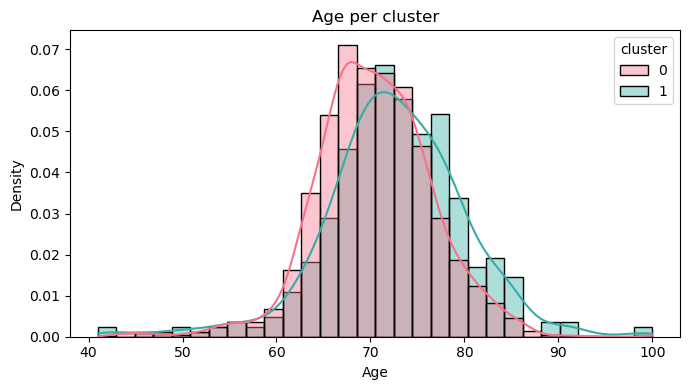

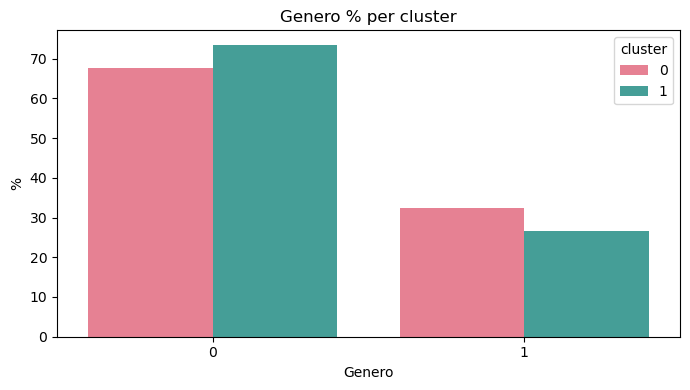

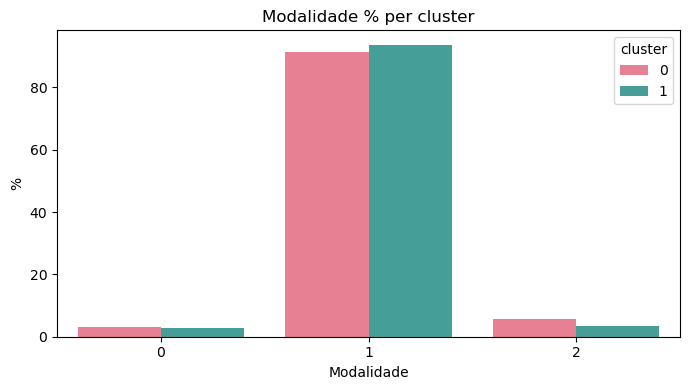

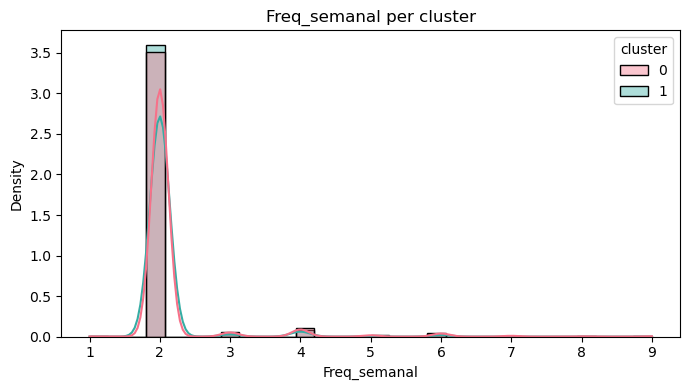

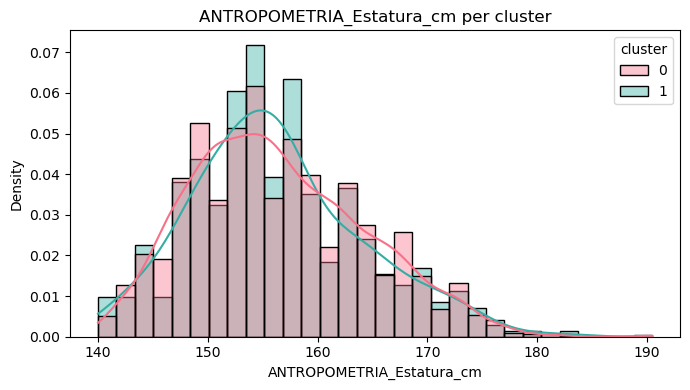

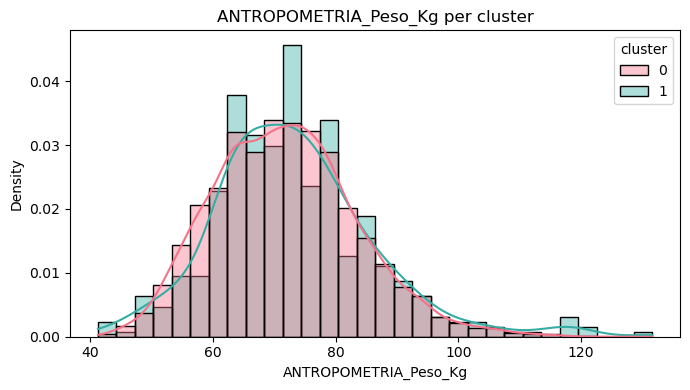

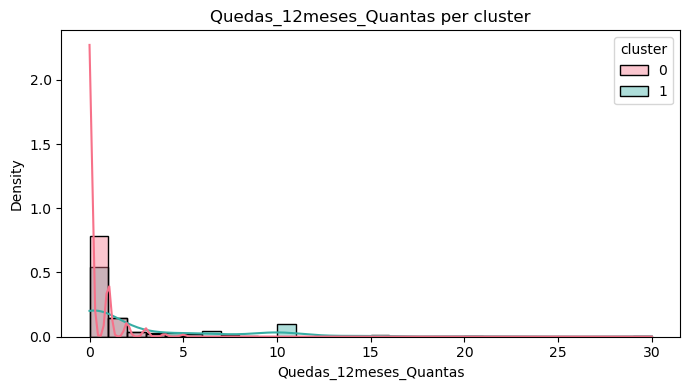

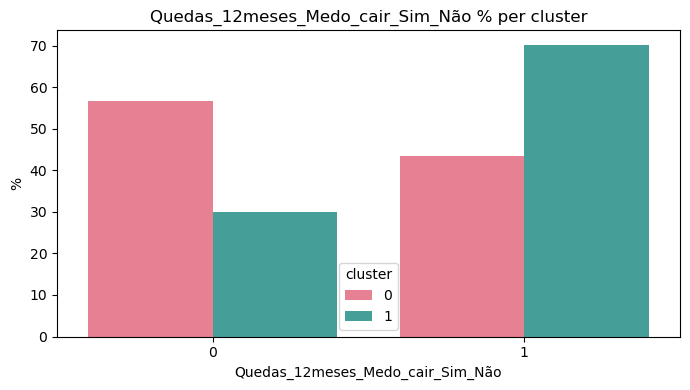

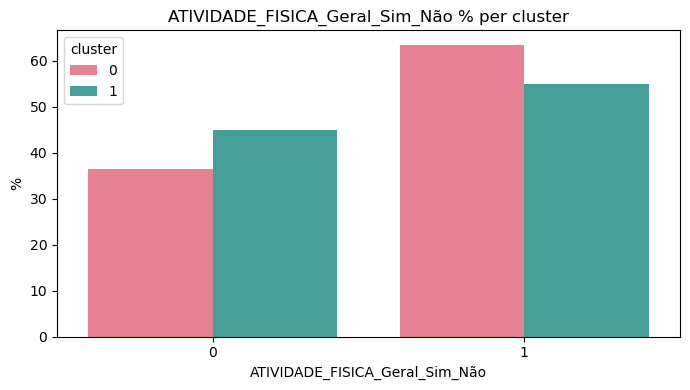

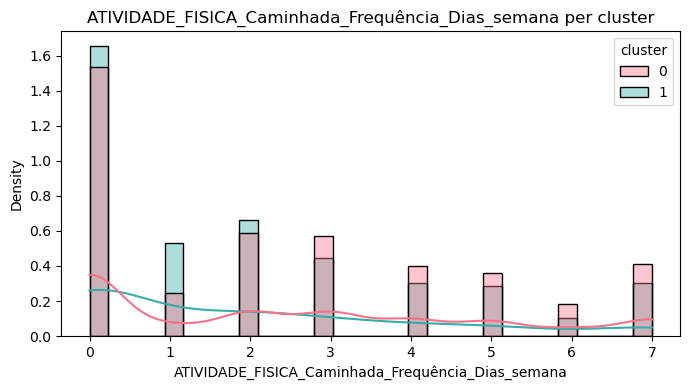

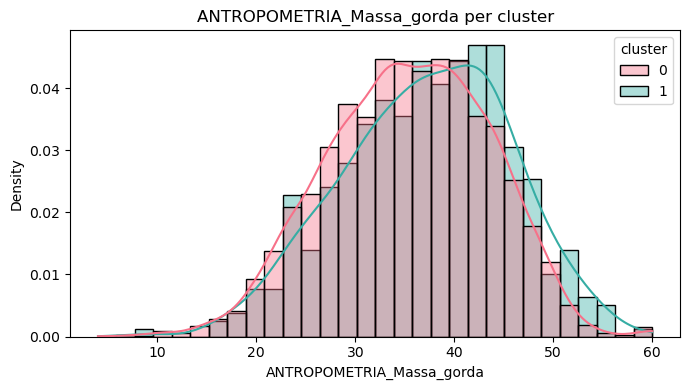

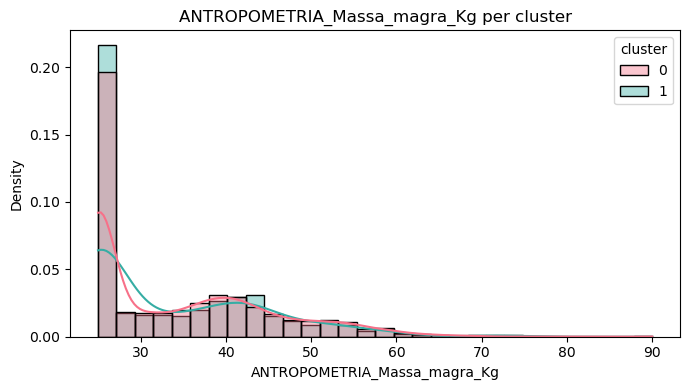

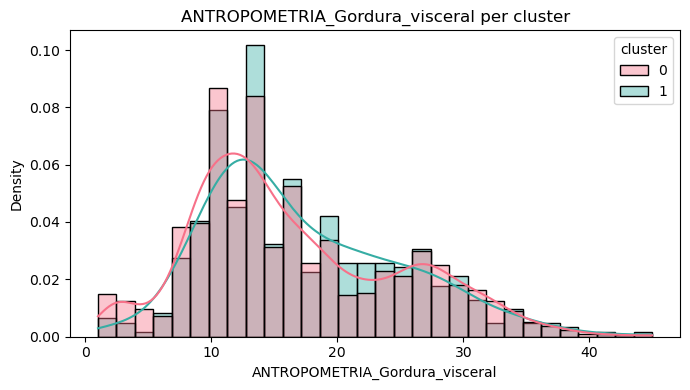

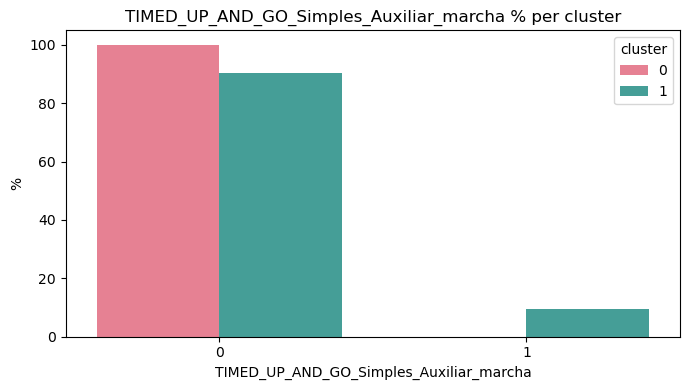

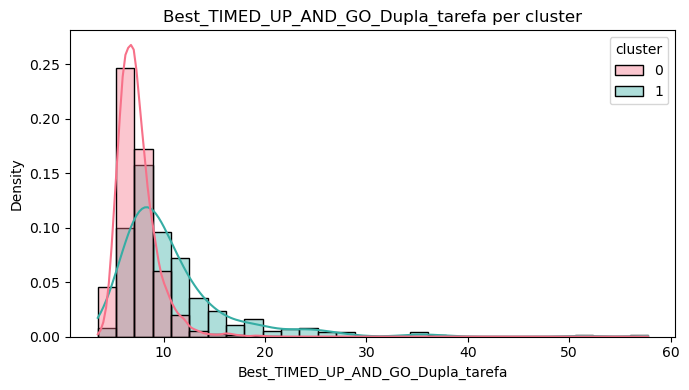

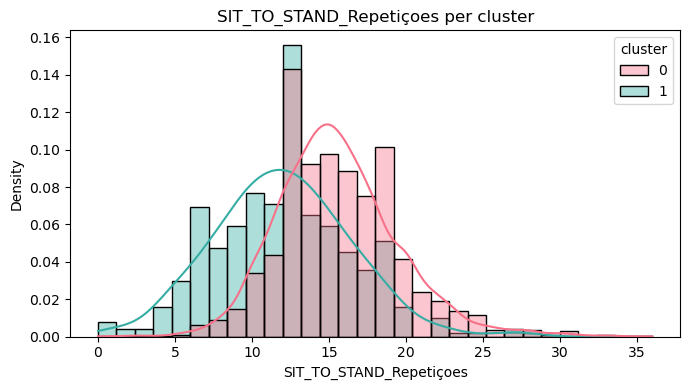

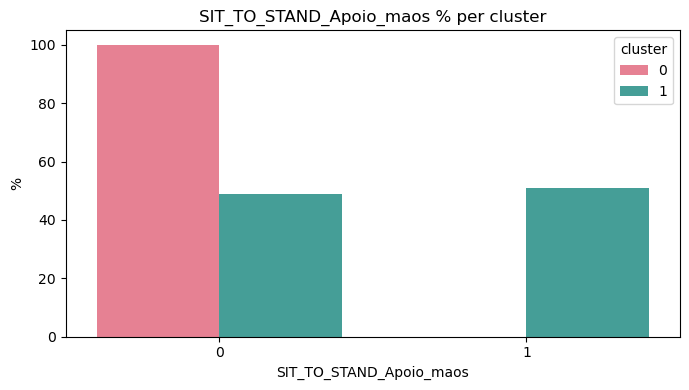

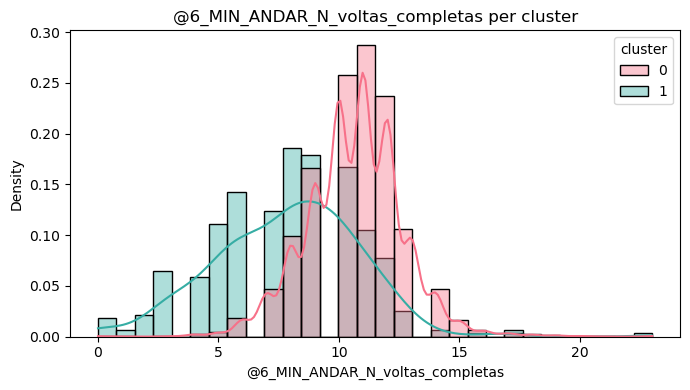

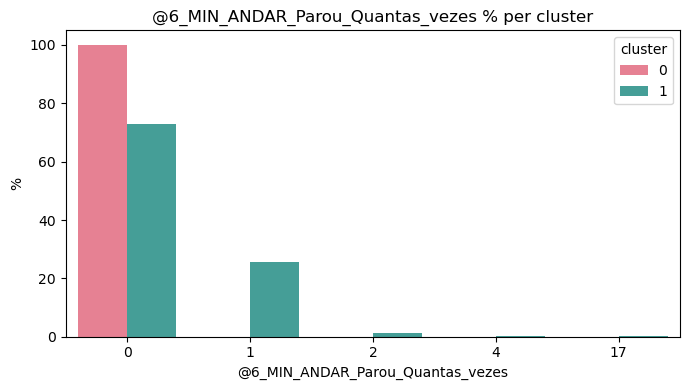

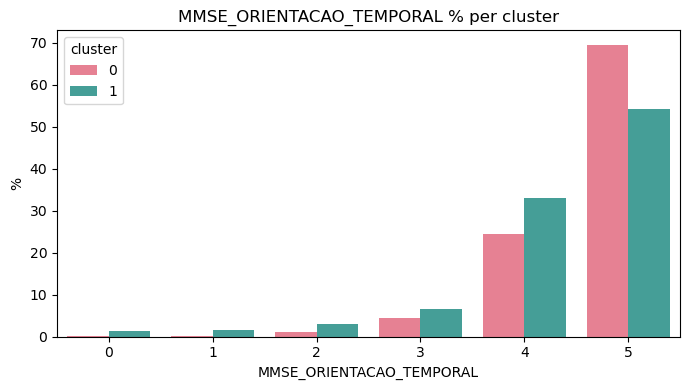

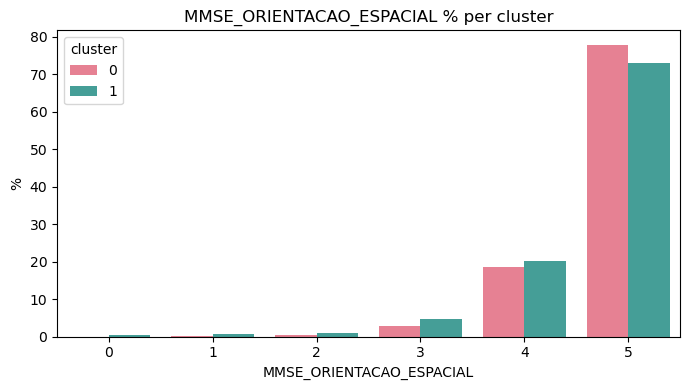

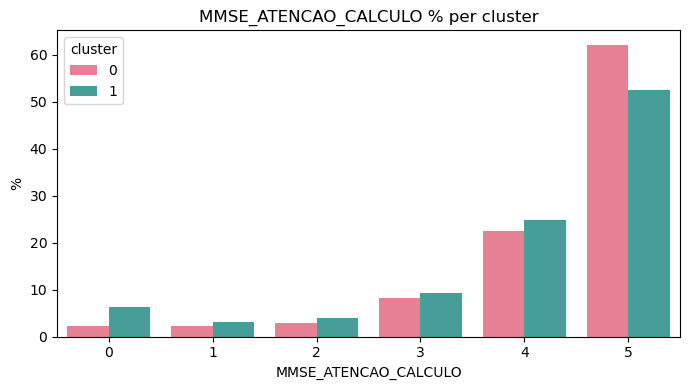

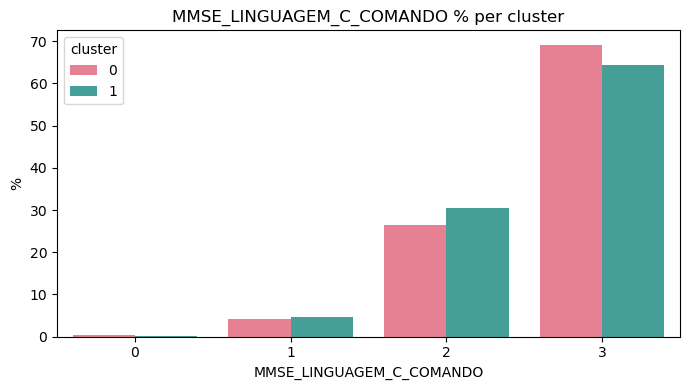

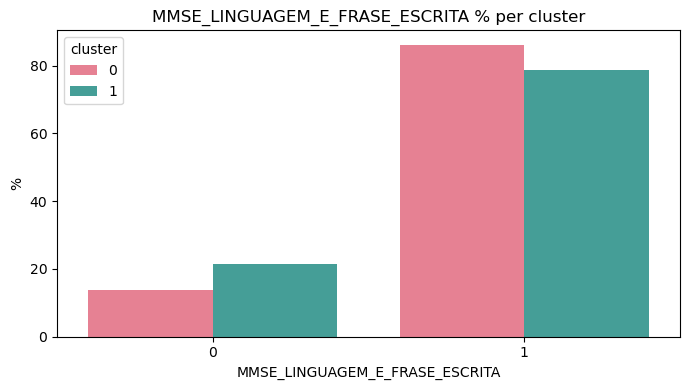

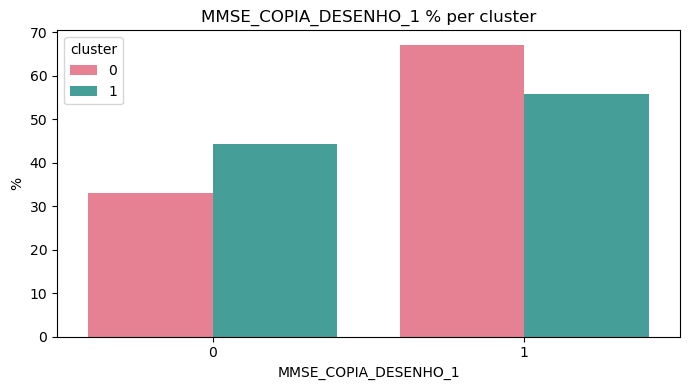

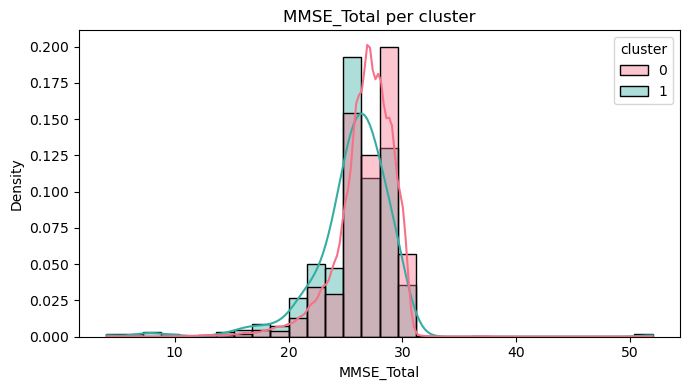

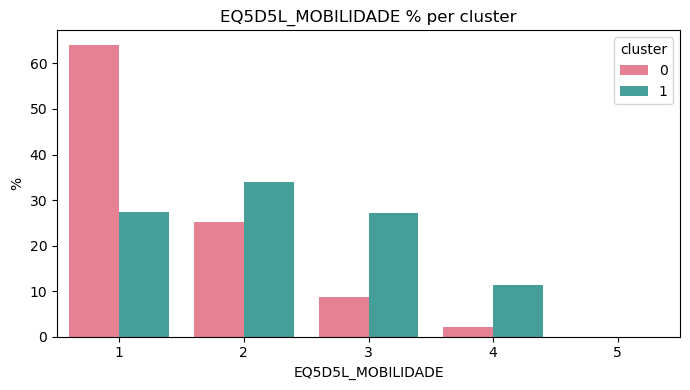

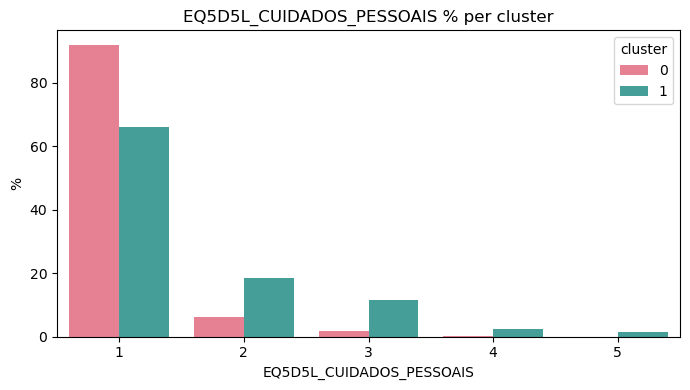

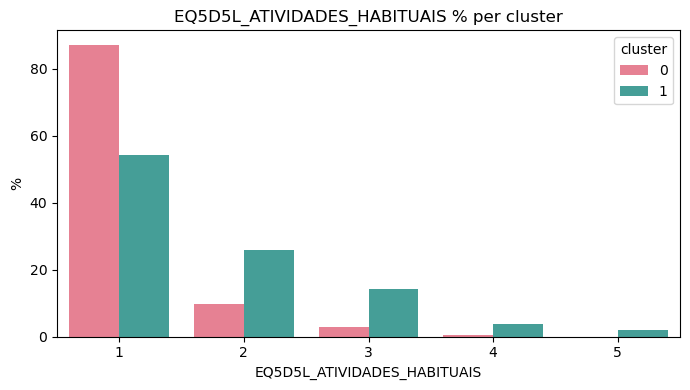

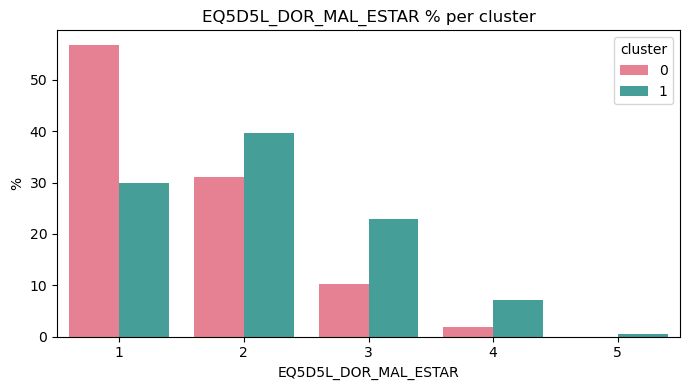

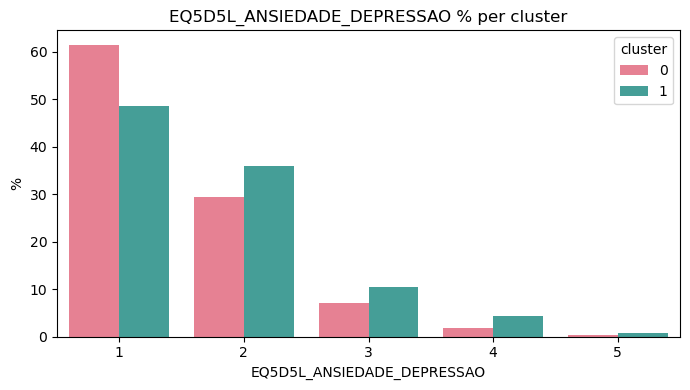

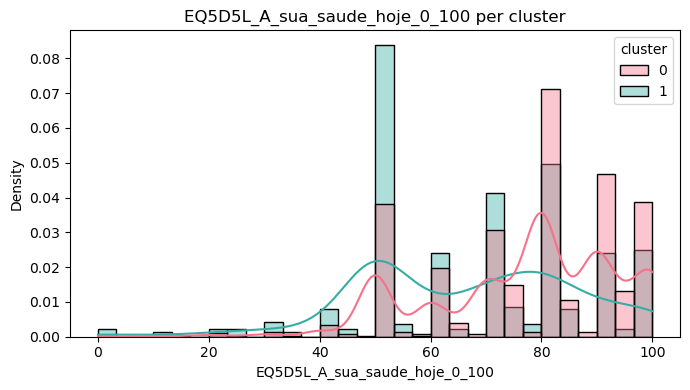

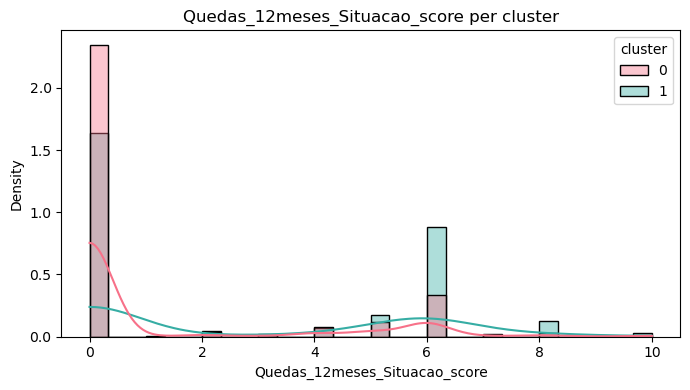

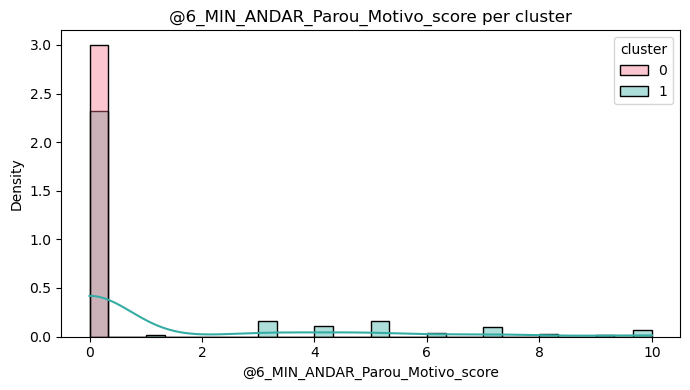

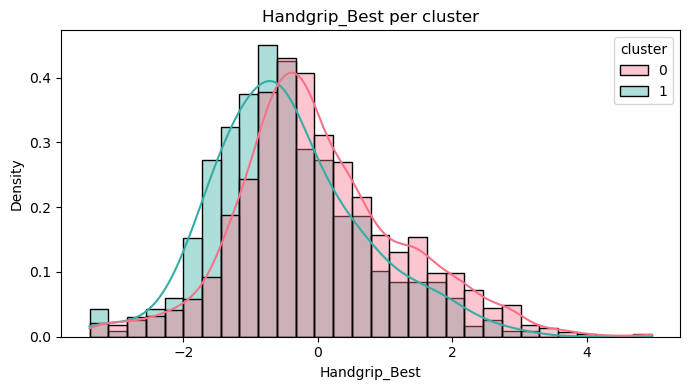

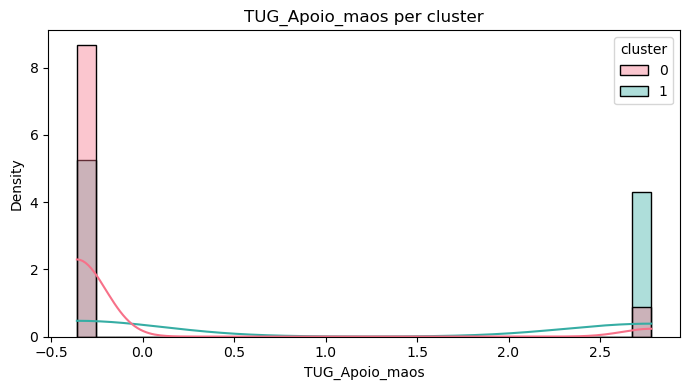

In [48]:
# Distribuições por cluster (todos os clusters)

df_plot = df_stats.copy()

cluster_col = "cluster"
vars_to_plot = X.columns.tolist()

# palette para todos os clusters
cluster_ids = sorted(df_plot[cluster_col].dropna().unique().tolist())
palette = sns.color_palette("husl", len(cluster_ids))
palette_map = dict(zip(cluster_ids, palette))

for col in vars_to_plot:
    plt.figure(figsize=(7, 4))

    unique_vals = df_plot[col].nunique(dropna=True)

    # --- Caso 1: poucas categorias numéricas inteiras -> barplot normalizado ---
    if pd.api.types.is_integer_dtype(df_plot[col]) and unique_vals <= 6:
        counts = (
            df_plot
            .groupby([cluster_col, col])
            .size()
            .reset_index(name="n")
        )

        # normalizar por cluster
        counts["pct"] = counts.groupby(cluster_col)["n"].transform(lambda x: x / x.sum() * 100)

        sns.barplot(
            data=counts,
            x=col,
            y="pct",
            hue=cluster_col,
            palette=palette_map
        )

        plt.title(f"{col} % per cluster")
        plt.ylabel("%")
        plt.xlabel(col)
        plt.xticks(rotation=0)

    # --- Caso 2: variável categórica não numérica ---
    elif not pd.api.types.is_numeric_dtype(df_plot[col]):
        counts = (
            df_plot
            .groupby([cluster_col, col])
            .size()
            .reset_index(name="n")
        )

        counts["pct"] = counts.groupby(cluster_col)["n"].transform(lambda x: x / x.sum() * 100)

        sns.barplot(
            data=counts,
            x=col,
            y="pct",
            hue=cluster_col,
            palette=palette_map
        )

        plt.title(f"{col} — distribuição (%) por cluster")
        plt.ylabel("%")
        plt.xlabel(col)
        plt.xticks(rotation=45, ha="right")

    # --- Caso 3: variável numérica contínua ---
    else:
        sns.histplot(
            data=df_plot,
            x=col,
            hue=cluster_col,
            kde=True,
            common_norm=False,
            stat="density",
            alpha=0.4,
            palette=palette_map,
            bins=30
        )

        plt.title(f"{col} per cluster")
        plt.xlabel(col)
        plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

## Testes estatísticos
### Depois de obtidas as  distribuições por cluster, realizamos testes estatísticos para determinar significância estatística. <br>

Os testes serão os seguintes: <br>

1. Testar diferenças entre clusters - testar normalidade com Shapiro-Wilk para cada variável dentro de cada cluster.

    Se todas as populações não rejeitarem normalidade (p > 0.05): <br>
    • 2 clusters: usar unpaired t-test <br>
    • ≥ 3 clusters: usar ANOVA (one-way) <br>

    Se alguma população rejeitar normalidade (p < 0.05): <br>
    • 2 clusters: usar Mann-Whitney U <br>
    • ≥ 3 clusters: usar Kruskal-Wallis <br>

In [49]:
# Diferenças estatísticas entre clusters

def diferencas_clusters(df, cluster_col, features):
    results = []
    clusters = sorted(df[cluster_col].dropna().unique())
    k = len(clusters)

    for col in features:
        s = df[[cluster_col, col]].dropna()
        if s.empty:
            continue

        n_unique = s[col].nunique()

        # CASO 1 - VARIÁVEL CATEGÓRICA (poucas categorias) (cluster x feature)
        if n_unique <= 5 or not pd.api.types.is_numeric_dtype(s[col]):

            tabela = pd.crosstab(s[col], s[cluster_col])

            stat, p, dof, expected = chi2_contingency(tabela)
            test_name = "Chi-square"

            results.append({
                "feature": col,
                "clusters": k,
                "normalidade_ok": None,
                "teste": test_name,
                "p_value_num": p,
            })
            continue

        # VARIÁVEL CONTÍNUA / ORDINAL
        grupos = [
            s[s[cluster_col] == c][col]
            for c in clusters
        ]

        # Normalidade (Shapiro)
        p_normalidades = []
        for g in grupos:
            if len(g) < 3:
                p_normalidades.append(0)
            else:
                _, p_sh = shapiro(g)
                p_normalidades.append(p_sh)

        normalidade_ok = all(p > 0.05 for p in p_normalidades)

        # Escolha do teste
        if normalidade_ok:
            if k == 2:
                stat, p = ttest_ind(grupos[0], grupos[1], equal_var=False)
                test_name = "t-test (Welch)"
            else:
                stat, p = f_oneway(*grupos)
                test_name = "ANOVA"
        else:
            if k == 2:
                stat, p = mannwhitneyu(grupos[0], grupos[1], alternative="two-sided")
                test_name = "Mann-Whitney U"
            else:
                stat, p = kruskal(*grupos)
                test_name = "Kruskal-Wallis"

        results.append({
            "feature": col,
            "clusters": k,
            "normalidade_ok": normalidade_ok,
            "teste": test_name,
            "p_value_num": p,
        })

    return pd.DataFrame(results)



features = X.columns.tolist()
df_tests = diferencas_clusters(df_stats, "cluster", features)

# Ordenar por p-value numérico ANTES de formatar
df_tests = df_tests.sort_values("p_value_num")

# Criar coluna única de p-value formatado
df_tests["p_value"] = df_tests["p_value_num"].apply(lambda x: f"{x:.3e}")

# Remover a coluna numérica
df_tests = df_tests.drop(columns=["p_value_num"])

display(df_tests)

print("\nVariáveis que mais diferenciam clusters (top 10):")
top_10 = df_tests.head(10)[["feature", "p_value"]]
print(top_10.to_string(index=False))

print("\nVariáveis que menos diferenciam clusters (top 5):")
top_5 = df_tests.tail(5)[["feature", "p_value"]]
print(top_5.to_string(index=False))


c:\Users\HP\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6283.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\HP\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6283.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\HP\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6283.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\HP\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6283.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\HP\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stat

,feature,clusters,normalidade_ok,teste,p_value
33,@6_MIN_ANDAR_Parou_Motivo_score,2,False,Mann-Whitney U,0.000e+00
18,@6_MIN_ANDAR_Parou_Quantas_vezes,2,None,Chi-square,0.000e+00
16,SIT_TO_STAND_Apoio_maos,2,None,Chi-square,0.000e+00
13,TIMED_UP_AND_GO_Simples_Auxiliar_marcha,2,None,Chi-square,7.395e-129
35,TUG_Apoio_maos,2,None,Chi-square,4.584e-110
28,EQ5D5L_ATIVIDADES_HABITUAIS,2,None,Chi-square,2.199e-100
27,EQ5D5L_CUIDADOS_PESSOAIS,2,None,Chi-square,8.460e-91
17,@6_MIN_ANDAR_N_voltas_completas,2,False,Mann-Whitney U,6.156e-89
26,EQ5D5L_MOBILIDADE,2,None,Chi-square,2.474e-77
14,Best_TIMED_UP_AND_GO_Dupla_tarefa,2,False,Mann-Whitney U,3.327e-69



Variáveis que mais diferenciam clusters (top 10):
                                feature    p_value
        @6_MIN_ANDAR_Parou_Motivo_score  0.000e+00
       @6_MIN_ANDAR_Parou_Quantas_vezes  0.000e+00
                SIT_TO_STAND_Apoio_maos  0.000e+00
TIMED_UP_AND_GO_Simples_Auxiliar_marcha 7.395e-129
                         TUG_Apoio_maos 4.584e-110
            EQ5D5L_ATIVIDADES_HABITUAIS 2.199e-100
               EQ5D5L_CUIDADOS_PESSOAIS  8.460e-91
        @6_MIN_ANDAR_N_voltas_completas  6.156e-89
                      EQ5D5L_MOBILIDADE  2.474e-77
      Best_TIMED_UP_AND_GO_Dupla_tarefa  3.327e-69

Variáveis que menos diferenciam clusters (top 5):
                     feature   p_value
       ANTROPOMETRIA_Peso_Kg 8.287e-02
ANTROPOMETRIA_Massa_magra_Kg 9.091e-02
                  Modalidade 1.943e-01
    MMSE_LINGUAGEM_C_COMANDO 2.025e-01
   ANTROPOMETRIA_Estatura_cm 8.167e-01


### Visualizações com U-Map / t-SNE

c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


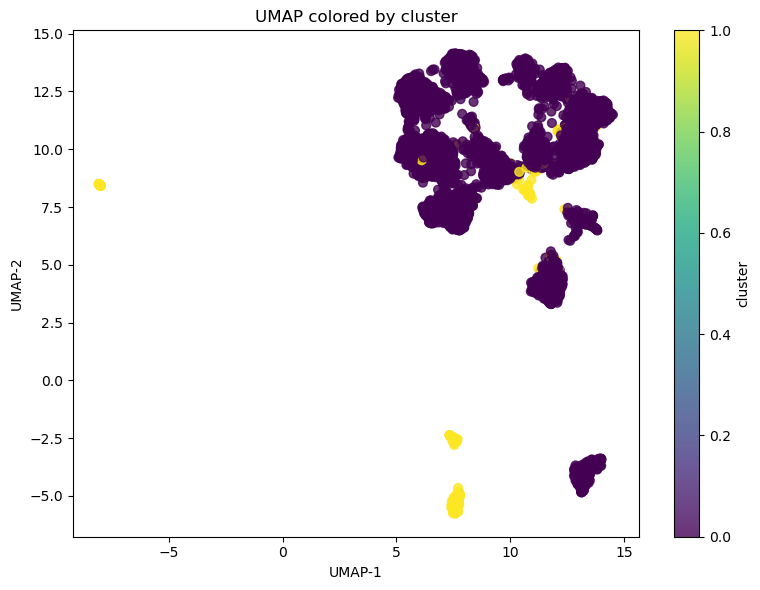

In [50]:
# escolher variável "alvo"
health_var = "cluster"
health = df_stats[health_var]

#  UMAP 
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=health,
    cmap="viridis",
    alpha=0.8,
    s=40
)
plt.colorbar(label=health_var)
plt.title(f"UMAP colored by {health_var}")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


In [51]:
# Correlação entre UMAP e variáveis originais

umap_df = pd.DataFrame({
    "umap1": embedding[:,0],
    "umap2": embedding[:,1]
})

# selecionar apenas variáveis numéricas
numeric_cols = df_stats.select_dtypes(include=[np.number]).columns

# matriz com UMAP + os dados numéricos
tmp = df_stats[numeric_cols].join(umap_df)

# correlação com UMAP-1
corr_umap1 = tmp[numeric_cols].corrwith(tmp["umap1"]).sort_values()
print("\nCorrelação com UMAP-1:")
print(corr_umap1)

# correlação com UMAP-2
corr_umap2 = tmp[numeric_cols].corrwith(tmp["umap2"]).sort_values()
print("\nCorrelação com UMAP-2:")
print(corr_umap2)



Correlação com UMAP-1:
ATIVIDADE_FISICA_Geral_Sim_Não                      -0.606532
TIMED_UP_AND_GO_Simples_Auxiliar_marcha             -0.440308
ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana   -0.416764
cluster                                             -0.219959
SIT_TO_STAND_Apoio_maos                             -0.191200
Genero                                              -0.152101
HANDGRIP_ESQUERDA_tentativa1                        -0.120181
ANTROPOMETRIA_Gordura_visceral                      -0.115944
HANDGRIP_ESQUERDA_tentativa2                        -0.111948
HANDGRIP_ESQUERDA_tentativa3                        -0.111767
Handgrip_Best                                       -0.111559
HANDGRIP_DIREITA_tentativa2                         -0.110808
HANDGRIP_DIREITA_tentativa_3                        -0.107763
HANDGRIP_DIREITA_tentativa_2                        -0.107763
@6_MIN_ANDAR_Parou                                  -0.106607
HANDGRIP_DIREITA_tentaiva1                    

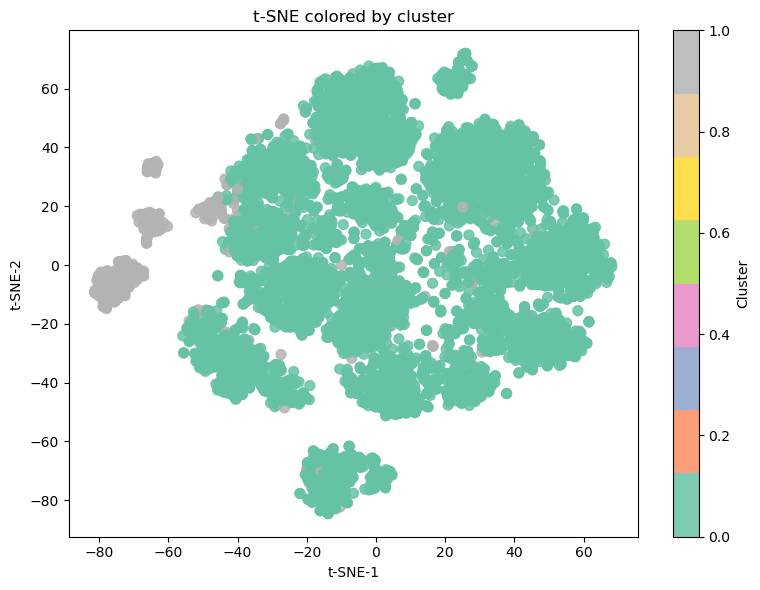

In [52]:
# clusters
cluster_labels = df_stats["cluster"]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

embedding = tsne.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=cluster_labels.map({c:i for i,c in enumerate(sorted(cluster_labels.unique()))}),
    cmap="Set2",
    alpha=0.85,
    s=50
)

plt.colorbar(label="Cluster")
plt.title("t-SNE colored by cluster")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()


In [53]:
# t-SNE embedding já calculado em `embedding`

tsne_df = pd.DataFrame({
    "tsne1": embedding[:, 0],
    "tsne2": embedding[:, 1]
}, index=df_stats.index)

# selecionar apenas variáveis numéricas (exclui a coluna 'cluster' se estiver numérica)
numeric_cols = df_stats.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c != "cluster"]

tmp = df_stats[numeric_cols].join(tsne_df)

corr_tsne1 = tmp[numeric_cols].corrwith(tmp["tsne1"]).sort_values()
print("\nCorrelação com t-SNE-1:")
print(corr_tsne1)

corr_tsne2 = tmp[numeric_cols].corrwith(tmp["tsne2"]).sort_values()
print("\nCorrelação com t-SNE-2:")
print(corr_tsne2)



Correlação com t-SNE-1:
TUG_Apoio_maos                                      -0.484464
Quedas_12meses_Medo_cair_Sim_Não                    -0.473291
TIMED_UP_AND_GO_Simples_Apoio_mãos                  -0.464691
TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos             -0.460837
Best_TIMED_UP_AND_GO_Simples                        -0.439213
TIMED_UP_AND_GO_Simples_tentativa2                  -0.436847
TIMED_UP_AND_GO_Simples_tentativa1                  -0.436841
SIT_TO_STAND_Apoio_maos                             -0.408059
TIMED_UP_AND_GO_Dupla_tarefa_tentativa1             -0.401218
Best_TIMED_UP_AND_GO_Dupla_tarefa                   -0.400486
Quedas_12meses_Situacao_score                       -0.392090
Quedas_ultimos_12meses                              -0.385828
TIMED_UP_AND_GO_Dupla_tarefa_tentativa2             -0.381600
EQ5D5L_MOBILIDADE                                   -0.381544
ANTROPOMETRIA_Massa_gorda                           -0.352907
Quedas_12meses_Quantas                       

## Ver quantas pessoas "trocaram" de cluster, e o que derivou essa mudança (2 clusters)

In [ ]:
ID_COL = "ID_Aluno"
TIME_COL = "Momento"
CL_COL = "cluster"

# Preparação
all_features = [c for c in df_stats.columns if c not in [ID_COL, TIME_COL, CL_COL]]
numeric_features = [f for f in all_features if pd.api.types.is_numeric_dtype(df_stats[f])]

df_sorted = df_stats.sort_values([ID_COL, TIME_COL]).reset_index(drop=True)
df_sorted[numeric_features] = df_sorted[numeric_features].apply(pd.to_numeric, errors="coerce")
df_sorted["next_cluster"] = df_sorted.groupby(ID_COL)[CL_COL].shift(-1)

# Deltas
next_vals = df_sorted.groupby(ID_COL)[numeric_features].shift(-1)
delta_df = next_vals - df_sorted[numeric_features]
delta_df.columns = [f"{c}_delta" for c in delta_df.columns]

df_sorted = pd.concat([df_sorted, delta_df], axis=1)
delta_cols = delta_df.columns.tolist()

# Identificação de transições
df_sorted["fez_transicao"] = (
    (df_sorted[CL_COL] != df_sorted["next_cluster"]) &
    (df_sorted["next_cluster"].notna())
)

mask = df_sorted["fez_transicao"]

df_sorted.loc[mask, "tipo_transicao"] = (
    df_sorted.loc[mask, CL_COL].astype(int).astype(str)
    + "->" +
    df_sorted.loc[mask, "next_cluster"].astype(int).astype(str)
)
df_sorted.loc[~mask, "tipo_transicao"] = None

# separar tipos de transição
transicoes_01 = df_sorted[df_sorted["tipo_transicao"] == "0->1"]
transicoes_10 = df_sorted[df_sorted["tipo_transicao"] == "1->0"]

# NORMALIZAÇÃO DOS DELTAS (Solução 2)
stds = df_sorted[numeric_features].std()

def normalized_deltas(df_transicao):
    # alinhar stds com nomes das colunas delta
    stds_delta = stds.copy()
    stds_delta.index = [f"{c}_delta" for c in stds_delta.index]
    return df_transicao[delta_cols].divide(stds_delta, axis=1)

norm_01 = normalized_deltas(transicoes_01)
norm_10 = normalized_deltas(transicoes_10)

# Análise por tipo de transição
def analisar_transicao_normalizada(df_norm, tipo):
    if len(df_norm) == 0:
        return
    
    print(f"\nTRANSIÇÕES {tipo}: {len(df_norm)} casos")
    mean_norm = df_norm.mean().sort_values(ascending=False)
    print("Top normalized deltas (mean Δ / std):")
    display(mean_norm.head)

analisar_transicao_normalizada(norm_01, "0->1")
analisar_transicao_normalizada(norm_10, "1->0")

# Comparação 0->1 vs 1->0
if len(norm_01) > 0 and len(norm_10) > 0:
    mean_norm_01 = norm_01.mean()
    mean_norm_10 = norm_10.mean()

    comparacao = pd.DataFrame({
        "0->1 (Δ/std média)": mean_norm_01,
        "1->0 (Δ/std média)": mean_norm_10,
        "Diferença (0->1 minus 1->0)": mean_norm_01 - mean_norm_10
    }).sort_values("Diferença (0->1 minus 1->0)", ascending=False)

    display(comparacao)



TRANSIÇÕES 0->1: 179 casos
Top normalized deltas (mean Δ / std):


<bound method NDFrame.head of SIT_TO_STAND_Apoio_maos_delta                              3.234238
Quedas_12meses_Quantas_delta                               1.210002
@6_MIN_ANDAR_Parou_delta                                   1.204702
@6_MIN_ANDAR_Parou_Motivo_score_delta                      1.100042
TIMED_UP_AND_GO_Simples_Apoio_mãos_delta                   0.939462
TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos_delta              0.916918
TUG_Apoio_maos_delta                                       0.912121
TIMED_UP_AND_GO_Simples_Auxiliar_marcha_delta              0.652869
@6_MIN_ANDAR_Parou_Quantas_vezes_delta                     0.639614
EQ5D5L_ATIVIDADES_HABITUAIS_delta                          0.555187
EQ5D5L_CUIDADOS_PESSOAIS_delta                             0.536065
ANTROPOMETRIA_Gordura_visceral_delta                       0.233764
Best_TIMED_UP_AND_GO_Simples_delta                         0.223490
TIMED_UP_AND_GO_Simples_tentativa1_delta                   0.207814
TIMED_UP_AND_GO_Si


TRANSIÇÕES 1->0: 164 casos
Top normalized deltas (mean Δ / std):


<bound method NDFrame.head of @6_MIN_ANDAR_N_voltas_completas_delta                      0.268429
Percentil_TIMED_UP_AND_GO_Dupla_tarefa_delta               0.227811
@6_MIN_ANDAR_Distancia_TOTAL_metros_delta                  0.226037
Percentil_TIMED_UP_AND_GO_Simples_delta                    0.196311
Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros_delta        0.177603
ANTROPOMETRIA_Massa_magra_Kg_delta                         0.126269
Age_delta                                                  0.091307
MMSE_LINGUAGEM_C_COMANDO_delta                             0.062877
ATIVIDADE_FISICA_Geral_Sim_Não_delta                       0.050493
EQ5D5L_A_sua_saude_hoje_0_100_delta                        0.036259
ANTROPOMETRIA_Estatura_cm_delta                            0.023341
ANTROPOMETRIA_Gordura_visceral_delta                       0.018802
MMSE_ORIENTACAO_TEMPORAL_delta                             0.017070
MMSE_ATENCAO_CALCULO_delta                                 0.015951
MMSE_EDUCAÇAO_delt

,0->1 (Δ/std média),1->0 (Δ/std média),Diferença (0->1 minus 1->0)
SIT_TO_STAND_Apoio_maos_delta,3.234238,-3.322402,6.556640
@6_MIN_ANDAR_Parou_delta,1.204702,-1.502730,2.707432
@6_MIN_ANDAR_Parou_Motivo_score_delta,1.100042,-1.182868,2.282910
Quedas_12meses_Quantas_delta,1.210002,-0.859486,2.069488
TIMED_UP_AND_GO_Simples_Apoio_mãos_delta,0.939462,-0.864543,1.804005
TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos_delta,0.916918,-0.880688,1.797606
TUG_Apoio_maos_delta,0.912121,-0.861531,1.773652
TIMED_UP_AND_GO_Simples_Auxiliar_marcha_delta,0.652869,-0.950110,1.602978
@6_MIN_ANDAR_Parou_Quantas_vezes_delta,0.639614,-0.770334,1.409948
EQ5D5L_ATIVIDADES_HABITUAIS_delta,0.555187,-0.297266,0.852453
